## Batch Parameters and Aggregation
This section lets you set parameters, call the R script for one or more CSVs, and aggregate results into a long-format summary where each row is a channel with `uL_mg_hr`, `temp_C`, and placeholder metadata.

In [2]:
import pandas as pd
import subprocess
from pathlib import Path

## Configuration

Set paths and default parameters.

In [3]:
# Paths
DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
OUT_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed')
R_SCRIPT = Path('/Users/oakley/Documents/GitHub/signal_respirometry/scripts/consumption_rate.R')

# Create output directory if needed
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Default parameters
DEFAULT_SAL = 33
DEFAULT_CONTROL = 'Ch1'
DEFAULT_CHANNELS = ['Ch2', 'Ch3', 'Ch4']
DEFAULT_MASSES = [0.00024, 0.00024, 0.00024]  # grams
DEFAULT_VOL_CONTROL = 0.002  # liters
DEFAULT_VOLUMES = [0.002, 0.002, 0.002]  # liters
DEFAULT_START_HOUR = 1
DEFAULT_END_HOUR = 8
DEFAULT_MICROBIAL_CUTOFF = 5

## Define Trial Runs

Each run is a dictionary with trial-specific parameters.

In [ ]:
# Define your runs here
# Each run can override defaults or use them

# Trial 1 (10 Nov 2025) - night environment
# Box2: small vessels (2ml), 1 animal each
# Box3: cylinders (260-268ml), 20 animals each
# Newbox: small vessels (2ml), 1 animal each - using newpyro CSV format

runs = [
    {
        'name': 'trial1-box2',
        'csv': DATA_DIR / 'Ostracods-trial1-box2-10Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box2',
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night',
            'trial': 'trial1'
        }
    },
    {
        'name': 'trial1-box3',
        'csv': DATA_DIR / 'Ostracods-trial1-box3-10Nov.csv',
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals × 0.00024 = 0.0048 g
        'volumes': [0.264, 0.262, 0.260],  # cylinders in ml → L
        'vol_control': 0.268,  # Ch1 control cylinder
        'metadata': {
            'brick': 'box3',
            'vessel': 'cylinder',
            'date': '10Nov2025',
            'environment': 'night',
            'trial': 'trial1'
        }
    },
    {
        'name': 'trial1-newbox',
        'csv': DATA_DIR / 'newpyro-trial1.csv',  # Using newpyro CSV format
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'newbox',
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night',
            'trial': 'trial1'
        }
    },
    # Trial 2 (11 Nov 2025) - night environment
    # NOTE: Box2 and Box3 had crashes during this trial
    # Only Newbox: medium vessels (25ml), 5 animals each
    {
        'name': 'trial2-newbox',
        'csv': DATA_DIR / 'newpyro-trial2.csv',  # Using newpyro CSV format
        'masses': [0.0012, 0.0012, 0.0012],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'brick': 'newbox',
            'vessel': 'medium',
            'date': '11Nov2025',
            'environment': 'night',
            'trial': 'trial2'
        }
    },
    # Trial 3 (12 Nov 2025) - night environment
    # Box2: cylinders (260, 262, 264, 268 ml), 20 animals each
    # Box3: medium vessels (25ml), 5 animals each
    # Newbox: small vessels (2ml), 1 animal each
    {
        'name': 'trial3-box2',
        'csv': DATA_DIR / 'Ostracods-trial3-box2-12Nov.csv',
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals × 0.00024 = 0.0048 g
        'volumes': [0.260, 0.262, 0.264],  # cylinders Ch2, Ch3, Ch4 in L
        'vol_control': 0.268,  # Ch1 control cylinder
        'metadata': {
            'brick': 'box2',
            'vessel': 'cylinder',
            'date': '12Nov2025',
            'environment': 'night',
            'trial': 'trial3',
            'notes': 'Ch2 closest to GoPro, Ch4 farthest from GoPro'
        }
    },
    {
        'name': 'trial3-box3',
        'csv': DATA_DIR / 'Ostracods-trial3-box3-12Nov.csv',
        'masses': [0.0012, 0.0012, 0.0012],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'brick': 'box3',
            'vessel': 'medium',
            'date': '12Nov2025',
            'environment': 'night',
            'trial': 'trial3'
        }
    },
    {
        'name': 'trial3-newbox',
        'csv': DATA_DIR / 'newpyro-trial3.csv',  # Using newpyro CSV format
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'newbox',
            'vessel': 'small',
            'date': '12Nov2025',
            'environment': 'night',
            'trial': 'trial3'
        }
    },
    # Trial 4 (13 Nov 2025) - night environment
    # Box2: small vessels (2ml), 1 animal each
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: cylinders (260, 262, 264, 268 ml), 20 animals each
    # NOTE: newpyro CSV needs manual conversion - only box2/box3 for now
    {
        'name': 'trial4-box2',
        'csv': DATA_DIR / 'Ostracods-trial4-box2-13Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box2',
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night',
            'trial': 'trial4'
        }
    },
    {
        'name': 'trial4-box3',
        'csv': DATA_DIR / 'Ostracods-trial4-box3-13Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box3',
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night',
            'trial': 'trial4'
        }
    },
    # Commented out - needs CSV conversion:
    # {
    #     'name': 'trial4-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial4-newbox-13Nov.csv',  # Needs conversion
    #     'masses': [0.0048, 0.0048, 0.0048],  # 20 animals per cylinder
    #     'volumes': [0.260, 0.262, 0.264],  # cylinders Ch2, Ch3, Ch4
    #     'vol_control': 0.268,  # Ch1 control cylinder
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'cylinder',
    #         'date': '13Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial4'
    #     }
    # },
    # Trial 4.5 (14 Nov 2025) - day environment (same animals as Trial 4)
    # Box2: small vessels (2ml), 1 animal each
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: cylinders - CSV needs conversion
    {
        'name': 'trial4.5-box2',
        'csv': DATA_DIR / 'Ostracods-trial4-light-box2-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box2',
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'trial': 'trial4.5',
            'notes': 'Same animals as trial4'
        }
    },
    {
        'name': 'trial4.5-box3',
        'csv': DATA_DIR / 'Ostracods-trial4-light-box3-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box3',
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'trial': 'trial4.5',
            'notes': 'Same animals as trial4'
        }
    },
    # Commented out - needs CSV conversion:
    # {
    #     'name': 'trial4.5-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial4-light-newbox-14Nov.csv',  # Needs conversion
    #     'masses': [0.0048, 0.0048, 0.0048],  # 20 animals per cylinder
    #     'volumes': [0.260, 0.262, 0.264],  # cylinders Ch2, Ch3, Ch4
    #     'vol_control': 0.268,  # Ch1 control cylinder
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'cylinder',
    #         'date': '14Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial4.5',
    #         'notes': 'Same animals as trial4'
    #     }
    # },
    # Trial 5 (14 Nov 2025) - night environment
    # Box2: cylinders (260, 262, 268 ml) - only 3 channels, one cylinder broke
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: small vessels (2ml), 1 animal each
    {
        'name': 'trial5-box2',
        'csv': DATA_DIR / 'Ostracods-trial5-box2-14Nov.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Only 3 channels
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals per cylinder
        'volumes': [0.260, 0.262, 0.268],  # Ch2=260ml, Ch3=262ml, Ch4=268ml
        'vol_control': 0.268,  # Using Ch4 (268ml) as pseudo-control
        'metadata': {
            'brick': 'box2',
            'vessel': 'cylinder',
            'date': '14Nov2025',
            'environment': 'night',
            'trial': 'trial5',
            'notes': 'One cylinder broke, only 3 channels available'
        }
    },
    {
        'name': 'trial5-box3',
        'csv': DATA_DIR / 'Ostracods-trial5-box3-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'brick': 'box3',
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night',
            'trial': 'trial5'
        }
    },
    # Commented out - needs CSV conversion:
    # {
    #     'name': 'trial5-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial5-newbox-14Nov.csv',  # Needs conversion
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '14Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial5'
    #     }
    # },
    # Trial 5.5 (15 Nov 2025) - day environment (same animals as Trial 5)
    # Box2: cylinders - NO CSV FILE for box2 light
    # Box3: small vessels, but control vessel broke - would need newbox control
    # Newbox: small vessels
    {
        'name': 'trial5.5-box2',
        'csv': DATA_DIR / 'Ostracods-trial5-box2-14Nov.csv',  # Reusing night CSV as placeholder
        'channels': ['Ch2', 'Ch3', 'Ch4'],
        'masses': [0.0048, 0.0048, 0.0048],
        'volumes': [0.260, 0.262, 0.268],
        'vol_control': 0.268,
        'metadata': {
            'brick': 'box2',
            'vessel': 'cylinder',
            'date': '15Nov2025',
            'environment': 'day',
            'trial': 'trial5.5',
            'notes': 'Same animals as trial5, one cylinder broke'
        }
    },
    # Commented out - box3 control vessel broke, needs newbox control data:
    # {
    #     'name': 'trial5.5-box3',
    #     'csv': DATA_DIR / 'Ostracods-trial5-light-box3-15Nov.csv',
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': ???,  # Control vessel broke, need to use newbox control
    #     'metadata': {
    #         'brick': 'box3',
    #         'vessel': 'small',
    #         'date': '15Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial5.5',
    #         'notes': 'Same animals as trial5, control vessel broke'
    #     }
    # },
    # Commented out - needs CSV conversion:
    # {
    #     'name': 'trial5.5-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial5-light-newbox-15Nov.csv',  # Needs conversion
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '15Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial5.5',
    #         'notes': 'Same animals as trial5'
    #     }
    # },
    # Trial 6 (16 Nov 2025) - day environment
    # Box3: small vessels (2ml), 1 animal each - Ch3 may have crashed
    # Newbox: small vessels (2ml), 1 animal each
    # NOTE: Only 1 control total - Ch1 on newpyro (newbox)
    # Commented out - needs CSV conversion for newbox:
    # {
    #     'name': 'trial6-box3',
    #     'csv': DATA_DIR / 'Ostracods-trial6-light-box3-16Nov.csv',
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': ???,  # Need to reference newbox Ch1 as control
    #     'metadata': {
    #         'brick': 'box3',
    #         'vessel': 'small',
    #         'date': '16Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial6',
    #         'notes': 'Ch3 may have crashed; control is Ch1 on newbox'
    #     }
    # },
    # {
    #     'name': 'trial6-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial6-light-newbox-16Nov.csv',  # Needs conversion
    #     'control': 'Ch1',  # This is the control for both box3 and newbox
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '16Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial6',
    #         'notes': 'Ch1 serves as control for both box3 and newbox'
    #     }
    # },
    # Trial 6.5 (16 Nov 2025) - night environment (same animals as Trial 6)
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: small vessels (2ml), 1 animal each
    # NOTE: Only 1 control - Ch1 on newbox
    # Commented out - needs CSV conversion for newbox:
    # {
    #     'name': 'trial6.5-box3',
    #     'csv': DATA_DIR / 'Ostracods-trial6-dark-box3-16Nov.csv',
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': ???,  # Need to reference newbox Ch1 as control
    #     'metadata': {
    #         'brick': 'box3',
    #         'vessel': 'small',
    #         'date': '16Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial6.5',
    #         'notes': 'Same animals as trial6; control is Ch1 on newbox'
    #     }
    # },
    # {
    #     'name': 'trial6.5-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial6-dark-newbox-16Nov.csv',  # Needs conversion
    #     'control': 'Ch1',  # This is the control for both box3 and newbox
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '16Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial6.5',
    #         'notes': 'Same animals as trial6; Ch1 serves as control for both box3 and newbox'
    #     }
    # },
    # Trial 7 (17 Nov 2025) - day environment
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: small vessels (2ml), 1 animal each
    # NOTE: Only 1 control total - Ch1 on newpyro (newbox)
    # Commented out - needs CSV conversion for newbox:
    # {
    #     'name': 'trial7-box3',
    #     'csv': DATA_DIR / 'Ostracods-trial7-light-box3-17Nov.csv',
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': ???,  # Need to reference newbox Ch1 as control
    #     'metadata': {
    #         'brick': 'box3',
    #         'vessel': 'small',
    #         'date': '17Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial7',
    #         'notes': 'Control is Ch1 on newbox'
    #     }
    # },
    # {
    #     'name': 'trial7-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial7-light-newbox-17Nov.csv',  # Needs conversion
    #     'control': 'Ch1',  # This is the control for both box3 and newbox
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '17Nov2025',
    #         'environment': 'day',
    #         'trial': 'trial7',
    #         'notes': 'Ch1 serves as control for both box3 and newbox'
    #     }
    # },
    # Trial 7.5 (17 Nov 2025) - night environment (same animals as Trial 7)
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: small vessels (2ml), 1 animal each
    # NOTE: Only 1 control - Ch1 on newbox
    # Commented out - needs CSV conversion for newbox:
    # {
    #     'name': 'trial7.5-box3',
    #     'csv': DATA_DIR / 'Ostracods-trial7-dark-box3-17Nov.csv',
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': ???,  # Need to reference newbox Ch1 as control
    #     'metadata': {
    #         'brick': 'box3',
    #         'vessel': 'small',
    #         'date': '17Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial7.5',
    #         'notes': 'Same animals as trial7; control is Ch1 on newbox'
    #     }
    # },
    # {
    #     'name': 'trial7.5-newbox',
    #     'csv': DATA_DIR / 'Ostracods-trial7-dark-newbox-17Nov.csv',  # Needs conversion
    #     'control': 'Ch1',  # This is the control for both box3 and newbox
    #     'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
    #     'volumes': [0.002, 0.002, 0.002],  # 2 ml each
    #     'vol_control': 0.002,
    #     'metadata': {
    #         'brick': 'newbox',
    #         'vessel': 'small',
    #         'date': '17Nov2025',
    #         'environment': 'night',
    #         'trial': 'trial7.5',
    #         'notes': 'Same animals as trial7; Ch1 serves as control for both box3 and newbox'
    #     }
    # },
]

## Helper Function: Call R Script

In [5]:
def run_respirometry_analysis(run, defaults=None):
    """
    Call consumption_rate.R for a single run.
    
    Args:
        run: dict with 'csv', 'name', and optional parameters
        defaults: dict with default values for missing parameters
    
    Returns:
        tuple: (success: bool, message: str)
    """
    if defaults is None:
        defaults = {}
    
    csv_path = run['csv']
    if not csv_path.exists():
        return False, f"CSV not found: {csv_path}"
    
    # Build R script arguments
    args = [
        'Rscript', '--vanilla', str(R_SCRIPT),
        '--csv', str(csv_path),
        '--sal', str(run.get('sal', defaults.get('sal', DEFAULT_SAL))),
        '--control', run.get('control', defaults.get('control', DEFAULT_CONTROL)),
        '--channels', ','.join(run.get('channels', defaults.get('channels', DEFAULT_CHANNELS))),
        '--masses', ','.join(str(m) for m in run.get('masses', defaults.get('masses', DEFAULT_MASSES))),
        '--vol_control', str(run.get('vol_control', defaults.get('vol_control', DEFAULT_VOL_CONTROL))),
        '--volumes', ','.join(str(v) for v in run.get('volumes', defaults.get('volumes', DEFAULT_VOLUMES))),
        '--start_hour', str(run.get('start_hour', defaults.get('start_hour', DEFAULT_START_HOUR))),
        '--end_hour', str(run.get('end_hour', defaults.get('end_hour', DEFAULT_END_HOUR))),
        '--microbial_cutoff_hour', str(run.get('microbial_cutoff_hour', defaults.get('microbial_cutoff_hour', DEFAULT_MICROBIAL_CUTOFF))),
        '--out', str(OUT_DIR),
    ]
    
    # Add optional flags if specified
    if run.get('mask_channels', False):
        args += ['--mask_channels', 'true']
    if 'cutoff_inclusive' in run:
        args += ['--cutoff_inclusive', 'true' if run['cutoff_inclusive'] else 'false']
    if run.get('debug', False):
        args += ['--debug', 'true']
    
    # Run R script
    try:
        result = subprocess.run(
            args,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        return True, f"Success: {run['name']}"
    except subprocess.CalledProcessError as e:
        error_msg = f"Failed: {run['name']}\n"
        if e.stderr:
            error_msg += f"Error: {e.stderr}"
        return False, error_msg

## Run Batch Analysis

In [26]:
# Process all runs
results = []

for run in runs:
    print(f"Processing {run['name']}...")
    success, message = run_respirometry_analysis(run)
    results.append({
        'name': run['name'],
        'success': success,
        'message': message
    })
    if not success:
        print(f"  ❌ {message}")
    else:
        print(f"  ✓ {message}")

# Summary
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Completed: {results_df['success'].sum()}/{len(results_df)} runs succeeded")
print(f"{'='*60}")
display(results_df)

Processing trial1-box2...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box3
Processing trial4.5-box2...
  ✓ Success: trial4-box3
Processing trial4.5-box2...
  ✓ Success: trial4.5-box2
P

,name,success,message
0,trial1-box2,True,Success: trial1-box2
1,trial1-box3,True,Success: trial1-box3
2,trial1-newbox,True,Success: trial1-newbox
3,trial2-newbox,True,Success: trial2-newbox
4,trial3-box2,True,Success: trial3-box2
5,trial3-box3,True,Success: trial3-box3
6,trial3-newbox,True,Success: trial3-newbox
7,trial4-box2,True,Success: trial4-box2
8,trial4-box3,True,Success: trial4-box3
9,trial4.5-box2,True,Success: trial4.5-box2


## Load and Aggregate Results

In [27]:
# Collect all R summary CSVs
summary_rows = []

for run in runs:
    csv_name = run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    if not summary_path.exists():
        print(f"Warning: Summary not found for {run['name']}")
        continue
    
    # Read R summary
    r_df = pd.read_csv(summary_path)
    
    # Get channels from run config
    channels = run.get('channels', DEFAULT_CHANNELS)
    
    # Extract per-channel results
    for ch in channels:
        col = f'{ch}_uL_mg_hr'
        if col in r_df.columns:
            row = {
                'name': run['name'],
                'file': str(run['csv']),
                'channel': ch,
                'uL_mg_hr': float(r_df[col].iloc[0]),
                'temp_C': float(r_df['temp_C'].iloc[0]) if 'temp_C' in r_df.columns else None,
            }
            # Add metadata if present
            if 'metadata' in run:
                row.update(run['metadata'])
            summary_rows.append(row)

# Create aggregated dataframe
if summary_rows:
    agg_df = pd.DataFrame(summary_rows)
    
    # Save aggregated summary
    agg_path = OUT_DIR / 'batch_summary.csv'
    agg_df.to_csv(agg_path, index=False)
    print(f"Aggregated summary saved to: {agg_path}")
    
    display(agg_df)
else:
    print("No results to aggregate.")

Aggregated summary saved to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


,name,file,channel,uL_mg_hr,temp_C,brick,vessel,date,environment,trial,notes
0,trial1-box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.554332,27.948,box2,small,10Nov2025,night,trial1,NaN
1,trial1-box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,3.209139,27.948,box2,small,10Nov2025,night,trial1,NaN
2,trial1-box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,3.297355,27.948,box2,small,10Nov2025,night,trial1,NaN
3,trial1-box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,12.986348,28.233,box3,cylinder,10Nov2025,night,trial1,NaN
4,trial1-box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,12.664716,28.233,box3,cylinder,10Nov2025,night,trial1,NaN
5,trial1-box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,11.633300,28.233,box3,cylinder,10Nov2025,night,trial1,NaN
6,trial1-newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.816339,27.921,newbox,small,10Nov2025,night,trial1,NaN
7,trial1-newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,2.995072,27.921,newbox,small,10Nov2025,night,trial1,NaN
8,trial1-newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,3.287139,27.921,newbox,small,10Nov2025,night,trial1,NaN
9,trial2-newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.833917,26.846,newbox,medium,11Nov2025,night,trial2,NaN


## Quick Statistics by Group


Summary statistics by group:


count      mean       std       min        max
vessel   environment                                                
cylinder day              3  0.934038  3.029542 -2.564141   2.696539
         night            9  6.253122  5.367619 -2.564141  12.986348
medium   night            6  3.311412  1.025452  2.100933   5.061329
small    day              6  0.952642  0.798171 -0.486397   1.948158
         night           18  1.629006  1.127290  0.077117   3.297355

/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_8933/3083916205.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,


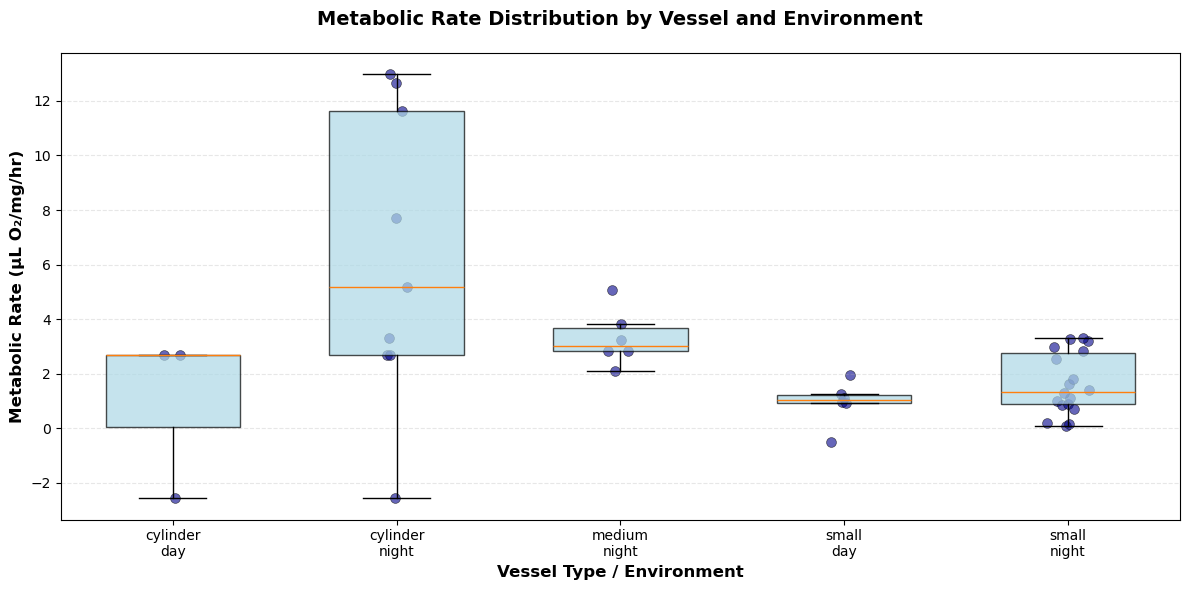

In [30]:
import matplotlib.pyplot as plt
import numpy as np

if 'agg_df' in locals() and not agg_df.empty:
    # Group by vessel and environment if those columns exist
    group_cols = [col for col in ['vessel', 'environment'] if col in agg_df.columns]
    
    if group_cols:
        stats = agg_df.groupby(group_cols)['uL_mg_hr'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)
        
        # Create box and whisker plot with individual data points
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create a combined grouping column for x-axis
        agg_df['group'] = agg_df['vessel'] + '\n' + agg_df['environment']
        
        # Get unique groups and sort them
        groups = agg_df['group'].unique()
        groups = sorted(groups)
        
        # Prepare data for box plot
        data_by_group = [agg_df[agg_df['group'] == g]['uL_mg_hr'].values for g in groups]
        
        # Create box plot
        bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,
                        widths=0.6, showfliers=False)
        
        # Style the boxes
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        # Overlay individual data points with jitter
        for i, group in enumerate(groups):
            y_data = agg_df[agg_df['group'] == group]['uL_mg_hr'].values
            # Add jitter to x positions
            x_data = np.random.normal(i + 1, 0.04, size=len(y_data))
            ax.scatter(x_data, y_data, alpha=0.6, s=50, c='darkblue', edgecolors='black', linewidth=0.5)
        
        # Labels and formatting
        ax.set_ylabel('Metabolic Rate (µL O₂/mg/hr)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vessel Type / Environment', fontsize=12, fontweight='bold')
        ax.set_title('Metabolic Rate Distribution by Vessel and Environment', fontsize=14, fontweight='bold', pad=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Rotate x-axis labels if needed
        plt.xticks(rotation=0, ha='center')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("\nOverall statistics:")
        print(agg_df['uL_mg_hr'].describe())
else:
    print("No data available for statistics.")

## Statistical Comparison: Day vs Night

Perform statistical tests to determine if metabolic rates differ significantly between day and night conditions.

In [31]:
from scipy import stats

if 'agg_df' in locals() and not agg_df.empty:
    # Test for each vessel type separately
    vessel_types = agg_df['vessel'].unique()
    
    print("Statistical Tests: Day vs Night Metabolic Rates")
    print("=" * 70)
    
    for vessel in vessel_types:
        vessel_data = agg_df[agg_df['vessel'] == vessel]
        
        day_data = vessel_data[vessel_data['environment'] == 'day']['uL_mg_hr'].values
        night_data = vessel_data[vessel_data['environment'] == 'night']['uL_mg_hr'].values
        
        if len(day_data) > 0 and len(night_data) > 0:
            # Perform t-test (assumes normality)
            t_stat, p_value_t = stats.ttest_ind(night_data, day_data)
            
            # Perform Mann-Whitney U test (non-parametric alternative)
            u_stat, p_value_u = stats.mannwhitneyu(night_data, day_data, alternative='two-sided')
            
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Night: n={len(night_data)}, mean={night_data.mean():.2f}, std={night_data.std():.2f}")
            print(f"  Day:   n={len(day_data)}, mean={day_data.mean():.2f}, std={day_data.std():.2f}")
            print(f"  Difference: {night_data.mean() - day_data.mean():.2f} µL O₂/mg/hr")
            print(f"  % Change: {((day_data.mean() - night_data.mean()) / night_data.mean() * 100):.1f}%")
            print(f"\n  Independent t-test:")
            print(f"    t-statistic = {t_stat:.3f}, p-value = {p_value_t:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_t < 0.05 else 'NOT significant'} at α=0.05")
            print(f"\n  Mann-Whitney U test (non-parametric):")
            print(f"    U-statistic = {u_stat:.1f}, p-value = {p_value_u:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_u < 0.05 else 'NOT significant'} at α=0.05")
        else:
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Insufficient data for comparison (day={len(day_data)}, night={len(night_data)})")
    
    print("\n" + "=" * 70)
else:
    print("No data available for statistical analysis.")

Statistical Tests: Day vs Night Metabolic Rates

SMALL VESSELS:
  Night: n=18, mean=1.63, std=1.10
  Day:   n=6, mean=0.95, std=0.73
  Difference: 0.68 µL O₂/mg/hr
  % Change: -41.5%

  Independent t-test:
    t-statistic = 1.352, p-value = 0.1902
    NOT significant at α=0.05

  Mann-Whitney U test (non-parametric):
    U-statistic = 68.0, p-value = 0.3781
    NOT significant at α=0.05

CYLINDER VESSELS:
  Night: n=9, mean=6.25, std=5.06
  Day:   n=3, mean=0.93, std=2.47
  Difference: 5.32 µL O₂/mg/hr
  % Change: -85.1%

  Independent t-test:
    t-statistic = 1.599, p-value = 0.1408
    NOT significant at α=0.05

  Mann-Whitney U test (non-parametric):
    U-statistic = 22.5, p-value = 0.1141
    NOT significant at α=0.05

MEDIUM VESSELS:
  Insufficient data for comparison (day=0, night=6)

